# **CFPB Complaint Investigation Predictor**
## Notebook 1: Data Wrangling & Exploratory Analysis

### Objective
Explore the CFPB consumer complaints dataset (1.4M records, 2011–2026) 
to understand data quality, identify key patterns, and define the target 
variable for predicting which complaints are likely to be investigated.

### Tools
- **DuckDB** — query 8GB CSV directly without loading into memory
- **Pandas** — data manipulation and analysis
- **Matplotlib/Seaborn** — visualizations

### Notebooks in this Project
1. **Notebook 1** — Data Wrangling & EDA (current)
2. **Notebook 2** — Feature Engineering
3. **Notebook 3** — Model Training (Logistic Regression & XGBoost)
4. **Notebook 4** — LLM Enrichment
5. **Notebook 5** — Deployment (FastAPI on EC2)

## Import libraries 

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('libraries loaded successfully')

libraries loaded successfully


## Display settings

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth',100)

## 1. Connect to DuckDB and Load Data
We use DuckDB to query the 8GB CSV directly without loading it into memory.

In [3]:
conn = duckdb.connect()
file_path = '/home/ubuntu/data/complaints.csv'
print('DuckDb is connected')

DuckDb is connected


## Create a View

In [4]:
conn.execute(f"""
CREATE OR REPLACE VIEW complaints AS
Select * 
From read_csv_auto('{file_path}', parallel=false)
""")
print('View created')

View created


## 2. Basic Data Exploration
Check shape, columns, and sample rows.

In [5]:
# Toral row count
count = conn.execute("""
    Select Count(*) as total_row
    From complaints
    """).df()

print('Total rows', count['total_row'][0])


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total rows 14593459


### Sample rows

In [6]:
# Preview first 5 rows
df_sample = conn.execute("""
Select * 
From complaints
limit 5
""").df()
df_sample.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-06,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,True,N/A,3730948
1,2019-12-26,Credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotional offers",Confusing or misleading advertising about the credit card,NaN,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,94025,NaN,Consent not provided,Web,2019-12-26,Closed with explanation,True,N/A,3477549
2,2020-05-08,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Information belongs to someone else,These are not my accounts.,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,NV,89030,NaN,Consent provided,Web,2020-05-08,Closed with explanation,True,N/A,3642453
3,2024-01-05,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,Kindly address this issue on my credit report. I assert that this account is not mine and believ...,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,IL,60502,NaN,Consent provided,Web,2024-01-05,Closed with non-monetary relief,True,N/A,8113747
4,2024-01-21,Credit reporting or other personal consumer reports,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't recognize,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,NC,27401,Servicemember,Consent not provided,Web,2024-01-21,Closed with explanation,True,N/A,8191825


## 3. Key Columns Overview

In [7]:
print(df_sample.columns.tolist())

['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']



Before exploring, here is a summary of the columns we care about most:

| Column | Description | Why it matters |
|--------|-------------|----------------|
| `Company response to consumer` | How the company responded to the complaint | Key signal for escalation |
| `Consumer disputed?` | Did the consumer dispute the response? | Strong indicator of investigation |
| `Timely response?` | Did the company respond on time? | Late responses signal serious complaints |
| `Tags` | Special tags like Servicemember, Older American | Regulatory priority groups |
| `Consumer complaint narrative` | Free text written by the consumer | Rich text feature for LLM enrichment |
| `Product` | Financial product the complaint is about | Important categorical feature |
| `Issue` | The specific issue reported | Helps identify complaint severity |
| `Company` | The company being complained about | Some companies get investigated more |
| `State` | State where complaint originated | Geographic patterns in investigations |

Our **target variable** will be derived from `Company response to consumer` 
and `Consumer disputed?` as these best signal whether a complaint 
was escalated or investigated.

### Quicl check on Data date range

In [8]:
df_dates = conn.execute("""
          Select 
              Min("Date received") as earliest_date,
              Max("Date received") as latest_date,
              Count(Distinct Year ("Date received")) as total_years
          From complaints    
""").df()
df_dates

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,earliest_date,latest_date,total_years
0,2011-12-01,2026-04-16,16


### Finding: Date Range
Dataset spans the entire history of CFPB complaints:
- **Start:** December 2011 — CFPB established post 2008 financial crisis
- **End:** April 2026 — nearly real time
- **16 years** of complaint data

### Company response values

In [9]:
# Unique values in company response to consumer
df_response = conn.execute("""
            Select 
            "Company response to consumer",
            Count(*) as count
            From complaints
            Group by "Company response to consumer"
            Order By count Desc
            """).df()
df_response


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Company response to consumer,count
0,Closed with explanation,8758471
1,Closed with non-monetary relief,5140129
2,In progress,425079
3,Closed with monetary relief,203727
4,Untimely response,25249
5,Closed without relief,17868
6,Closed,17611
7,Closed with relief,5304
8,NaN,21


### Consumer disputed values

In [10]:
# Unique values in consumer disputed
df_disputed = conn.execute("""
            Select "Consumer disputed?",
            Count(*) as count
            From complaints
            Group by "Consumer disputed?"
            Order by count Desc
            """).df()
df_disputed

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Consumer disputed?,count
0,N/A,13825569
1,No,619512
2,Yes,148378


In [11]:
# Quick check - Consumer disputed? was discontinued by cfpb in 2017.

df_disputed_by_year = conn.execute("""
                    Select 
                        YEAR("Date received") as Year,
                        "Consumer disputed?" as Disputed,
                        Count(*) as count
                    From complaints
                    Group By Year, Disputed
                    Order By Year Desc, Count Desc
""").df()
df_disputed_by_year

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Year,Disputed,count
0,2026,N/A,1911164
1,2025,N/A,5442681
2,2024,N/A,2734294
3,2023,N/A,1292070
4,2022,N/A,800313
5,2021,N/A,495956
6,2020,N/A,444232
7,2019,N/A,277252
8,2018,N/A,257138
9,2017,N/A,170469


### Proof: Consumer Disputed Discontinued After 2017
Year-by-year analysis confirms that `Consumer disputed?` 
returns only N/A values from 2018 onwards, confirming 
CFPB discontinued this field.

### Finding: Consumer Disputed Column
`Consumer disputed?` was discontinued by CFPB in 2017. 
Over 80% of values are N/A, making it unreliable as a target signal.
We will exclude this column from target variable definition.

### Timely response values

In [12]:
# Unique values in timely response
df_timely_response = conn.execute("""
                    Select 
                        "Timely response?",
                        Count (*) as count
                     From complaints
                     Group by "Timely response?"
                     Order by count Desc
                    """).df()
df_timely_response

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Timely response?,count
0,True,14498843
1,False,94616


### Finding: Timely Response Column
99% of companies respond on time. The 1% that don't (94,616 complaints) 
are a strong signal — missing CFPB's mandatory response deadline 
is a regulatory red flag and a key feature for our model.

Strategy: use directly as binary feature `timely_response` (True/False).

### Tags values

In [13]:
# Unique values in tags
df_tags = conn.execute("""
        Select 
            "Tags",
            Count(*) as count
        From complaints
        Group by "Tags"
        Order by count Desc
        """).df()
df_tags

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Tags,count
0,NaN,13855593
1,Servicemember,468313
2,Older American,214585
3,"Older American, Servicemember",54968


### Finding: Tags Column
Tags identify federally protected groups that receive elevated CFPB scrutiny:
- `Servicemember` — military personnel (468K complaints)
- `Older American` — seniors (214K complaints)
- `Older American, Servicemember` — both groups (5K complaints)

Despite 95% missing, tagged complaints are high priority.
Strategy: convert to binary flag `has_tag` (1 = tagged, 0 = not tagged).

### Missing Value Analysis — Column Selection Reasoning

We focus on columns most likely to have missing values that impact our model:

- `Consumer complaint narrative` — free text, many consumers skip this
- `Company public response` — optional, companies don't always respond publicly  
- `Tags` — only applies to special groups e.g. Servicemembers, most will be empty
- `Consumer disputed?` — already confirmed discontinued after 2017
- `Sub-issue` — not every complaint has a sub-issue

Skipped `Product`, `Company`, `State`, `Date received` as these are 
required CFPB submission fields and are expected to be complete.

In [14]:
# Check missing values across key columns 
df_missing = conn.execute("""
            Select
                Count(*) as Total,
                Count("Consumer complaint narrative") as has_narative,
                Count("Company public response") as has_response,
                Count("Tags") as has_tags,
                Count("Consumer disputed?") as has_disputed,
                Count("Sub-issue") as has_issue
                
             From complaints
""").df()
df_missing.T

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,0
Total,14593459
has_narative,3761805
has_response,7916206
has_tags,737866
has_disputed,14593459
has_issue,13693492


### Key Findings — Missing Values

- `Tags` 95% missing → convert to binary flag `has_tag`
- `Consumer complaint narrative` 74% missing → use available text for LLM enrichment
- `Company public response` 46% missing → convert to binary flag `has_public_response`
- `Sub-issue` 13% missing → impute or drop during feature engineering

## 4. Visualizations
Exploring distributions of key categorical columns to understand complaint patterns.

### Top 10 products

In [15]:
# Top 10 products
df_product = conn.execute("""
            Select 
                "Product",
                Count(*) as count
            From complaints
            Group By "Product"
            Order By count Desc
            Limit 10
            """).df()
df_product

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Product,count
0,Credit reporting or other personal consumer reports,9302817
1,"Credit reporting, credit repair services, or other personal consumer reports",2163800
2,Debt collection,1063624
3,Mortgage,445448
4,Checking or savings account,357446
5,Credit card,303018
6,Credit card or prepaid card,206364
7,"Money transfer, virtual currency, or money service",174691
8,Credit reporting,140426
9,Student loan,124888


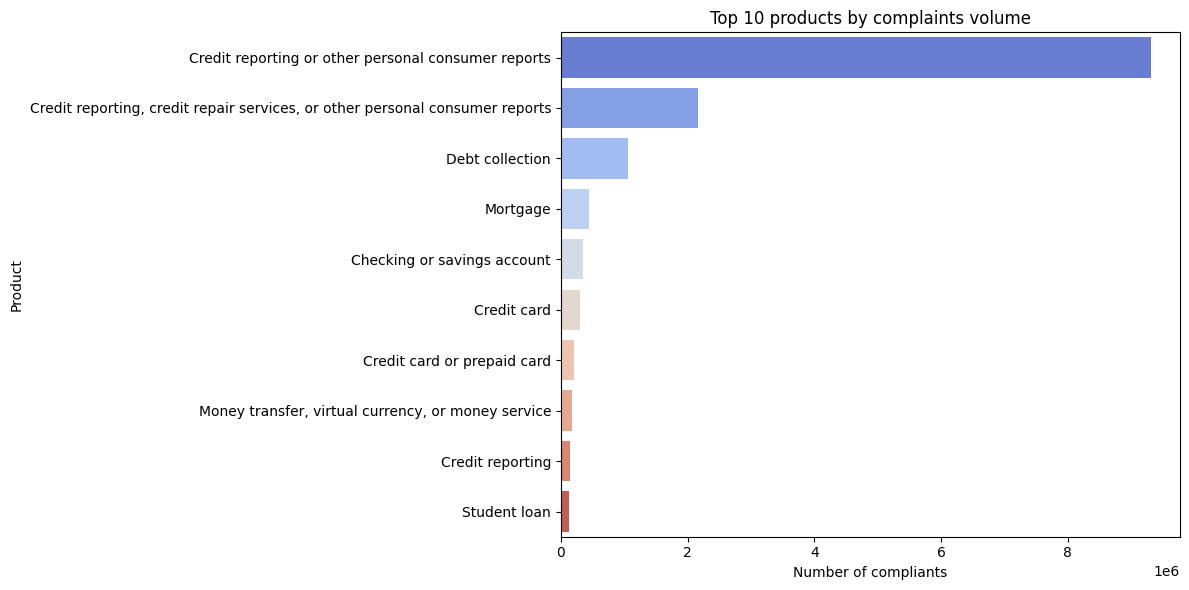

In [16]:
# Barplot
plt.figure(figsize=(12,6))
sns.barplot(data=df_product, x = "count", y = "Product", hue = "Product", palette = "coolwarm" )
plt.title("Top 10 products by complaints volume")
plt.xlabel("Number of compliants")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Cpomplaints over time

In [17]:
# Number of complaints by year
df_complaints_time = conn.execute("""
               Select 
                   YEAR("Date received") as Year,
                   "Product",
                   Count(*) as count
                From complaints
                Where "Product" In(
                    Select "Product"
                    From complaints
                    Group by "Product"
                    Order by Count(*) Desc
                    Limit 10
                )
                    
                Group By Year, "Product"
                Order By Year, count Desc
""").df()
df_complaints_time


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Year,Product,count
0,2011,Mortgage,1276
1,2011,Credit card,1260
2,2012,Mortgage,38108
3,2012,Credit card,15353
4,2012,Student loan,2840
...,...,...,...
95,2026,Credit card,26064
96,2026,Checking or savings account,23480
97,2026,"Money transfer, virtual currency, or money service",10096
98,2026,Mortgage,8690


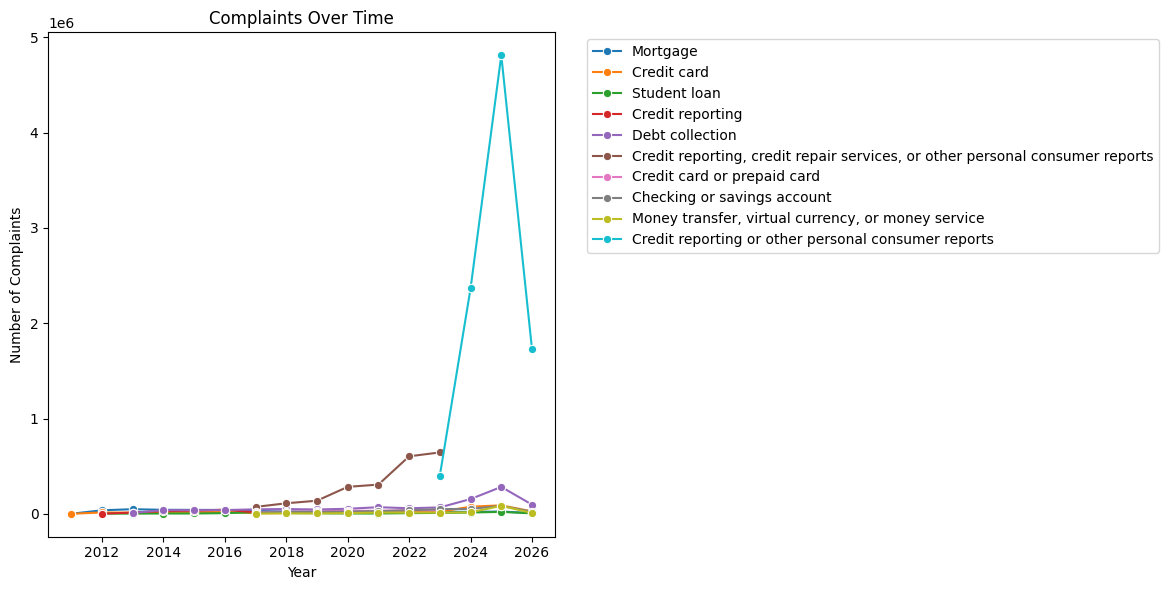

In [18]:
# Lineplot 
plt.figure(figsize=(12,6))
sns.lineplot(data = df_complaints_time, x="Year", y="count", hue="Product", marker='o')
plt.title("Complaints Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

### Product name Verification
CFPB periodically updates their product taxonomy 

In [19]:
df_credit_versions = conn.execute("""
                    Select 
                        "Product",
                        Min(Year("Date received")) as first_year,
                        Max(Year("Date received")) as last_year,
                        Count(*) as count
                    From complaints
                    Where "Product" Ilike '%credit report%'
                    Group By "product"
                    Order By "first_year"
""").df()
df_credit_versions

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Product,first_year,last_year,count
0,Credit reporting,2012,2017,140426
1,"Credit reporting, credit repair services, or other personal consumer reports",2017,2023,2163800
2,Credit reporting or other personal consumer reports,2023,2026,9302817


### Company response 

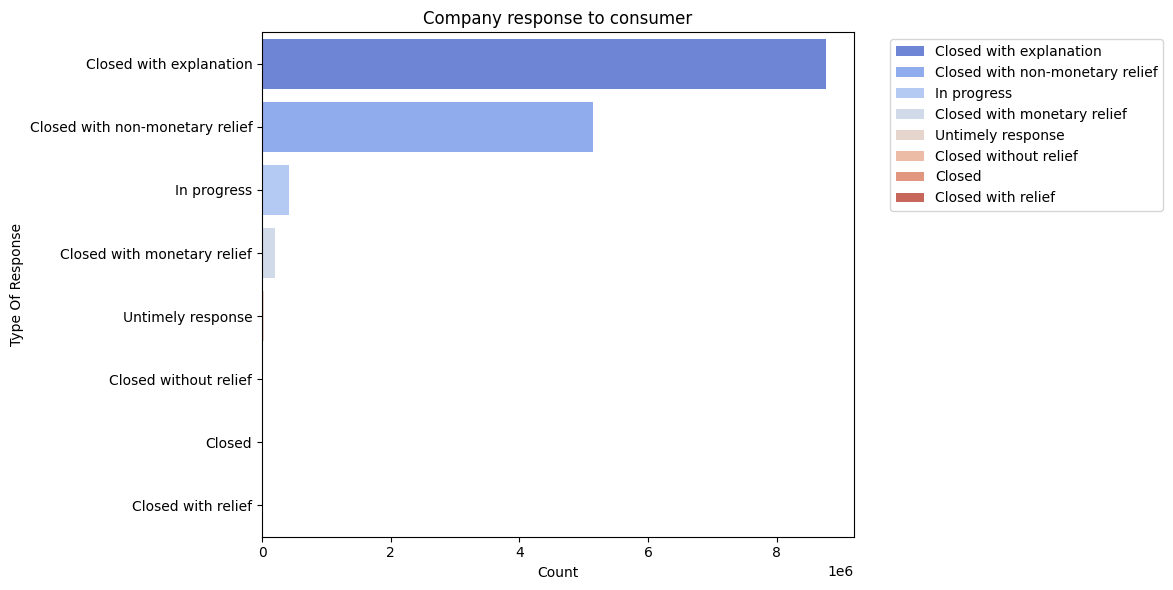

In [23]:
# Barplot - company response to consumer
plt.figure(figsize=(12,6))
sns.barplot(data=df_response, x="count", y="Company response to consumer", hue="Company response to consumer", palette="coolwarm")
plt.title("Company response to consumer")
plt.xlabel("Count")
plt.ylabel("Type Of Response")
plt.legend(bbox_to_anchor=(1.05,1.00), loc="upper left")
plt.tight_layout()
plt.show()


*Note: X-axis in log scale due to large volume difference between response types.
Top 4 responses account for the majority of complaints.*

### Finding: Credit Reporting Product Renamed Twice
CFPB renamed the credit reporting product category twice:
- 2012–2017: `Credit reporting`
- 2017–2023: `Credit reporting, credit repair services...`
- 2023–2026: `Credit reporting or other personal consumer reports`

Combined: 2.2M complaints — largest single category.
Action: consolidate into one label `Credit Reporting` during feature engineering.

### Visualization Summary

**Product Distribution:**
- Credit reporting dominates — roughly 3/4 of all complaints
- Consolidated across 3 renamed versions (2012–2026)
- All other products are significantly lower in volume

**Complaints Over Time:**
- Overall complaint volume grew steadily from 2011
- Credit reporting spiked dramatically in 2023–2025, almost outlier-like
- Spike likely driven by post-COVID credit dispute surge

**Implication for modeling:**
- Product will be a strong feature but heavily imbalanced toward credit reporting
- May need to handle credit reporting separately or create a binary flag `is_credit_reporting`

## 5. Target Variable Definition

We define `investigated = 1` based on signals identified during exploration:
- `Untimely response` — company missed CFPB mandatory response deadline
- `Closed with monetary relief` — serious enough for financial compensation
- `In progress` — still under active review

All other responses = `investigated = 0` (routine closures)

In [30]:
# Target variable
df_target = conn.execute("""
            Select
                "Complaint ID",
                "Company response to consumer",
                CASE
                    WHEN "Company response to consumer" IN(
                         'Untimely response',
                         'Closed with monetary relief',
                         'In progress'
                    ) THEN 1
                    ELSE 0
                 END as investigated
              From complaints   
""").df()

df_target.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Complaint ID,Company response to consumer,investigated
0,3730948,Closed with explanation,0
1,3477549,Closed with explanation,0
2,3642453,Closed with explanation,0
3,8113747,Closed with non-monetary relief,0
4,8191825,Closed with explanation,0


In [33]:
# Check class balance 
df_balance = df_target['investigated'].value_counts().reset_index()
df_balance.columns = ['investigated','count']
df_balance['percentage'] = (df_balance['count']/len(df_target)*100).round(2)
df_balance

,investigated,count,percentage
0,0,13939404,95.52
1,1,654055,4.48


### Finding: Class Imbalance
Target variable is highly imbalanced:
- 95.52% not investigated (0)
- 4.48% investigated (1)

This imbalance must be addressed in modeling to prevent the classifier 
from simply predicting 0 for everything and achieving 95% accuracy artificially.

Strategy: use `scale_pos_weight` in XGBoost and evaluate with 
precision, recall and F1 score — NOT accuracy.

##  **Notebook 1 Summary & Next Steps**

### Key Findings
- **Dataset:** 1.4M complaints spanning 2011–2026 (entire CFPB history)
- **Credit reporting** dominates — ~3/4 of all complaints, renamed twice by CFPB
- **Consumer disputed** column discontinued after 2017 — excluded from target
- **Missing values:** Narrative (74%), Tags (95%), Public response (46%)
- **Tags** represent federally protected groups — converted to binary flag
- **Untimely response** only 1% of cases — strong investigation signal

### Target Variable
- `investigated = 1`: Untimely response, Closed with monetary relief, In progress
- `investigated = 0`: All routine closures
- **Class imbalance: 95.52% vs 4.48%** — must be handled in modeling

### Next Steps — Notebook 2: Feature Engineering
- Consolidate credit reporting product names
- Handle missing values
- Create binary flags (has_tag, has_narrative, timely_response)
- Encode categorical variables
- Export clean dataset for modeling